# 유통데이터 활용 경진대회 (수요예측 부문)


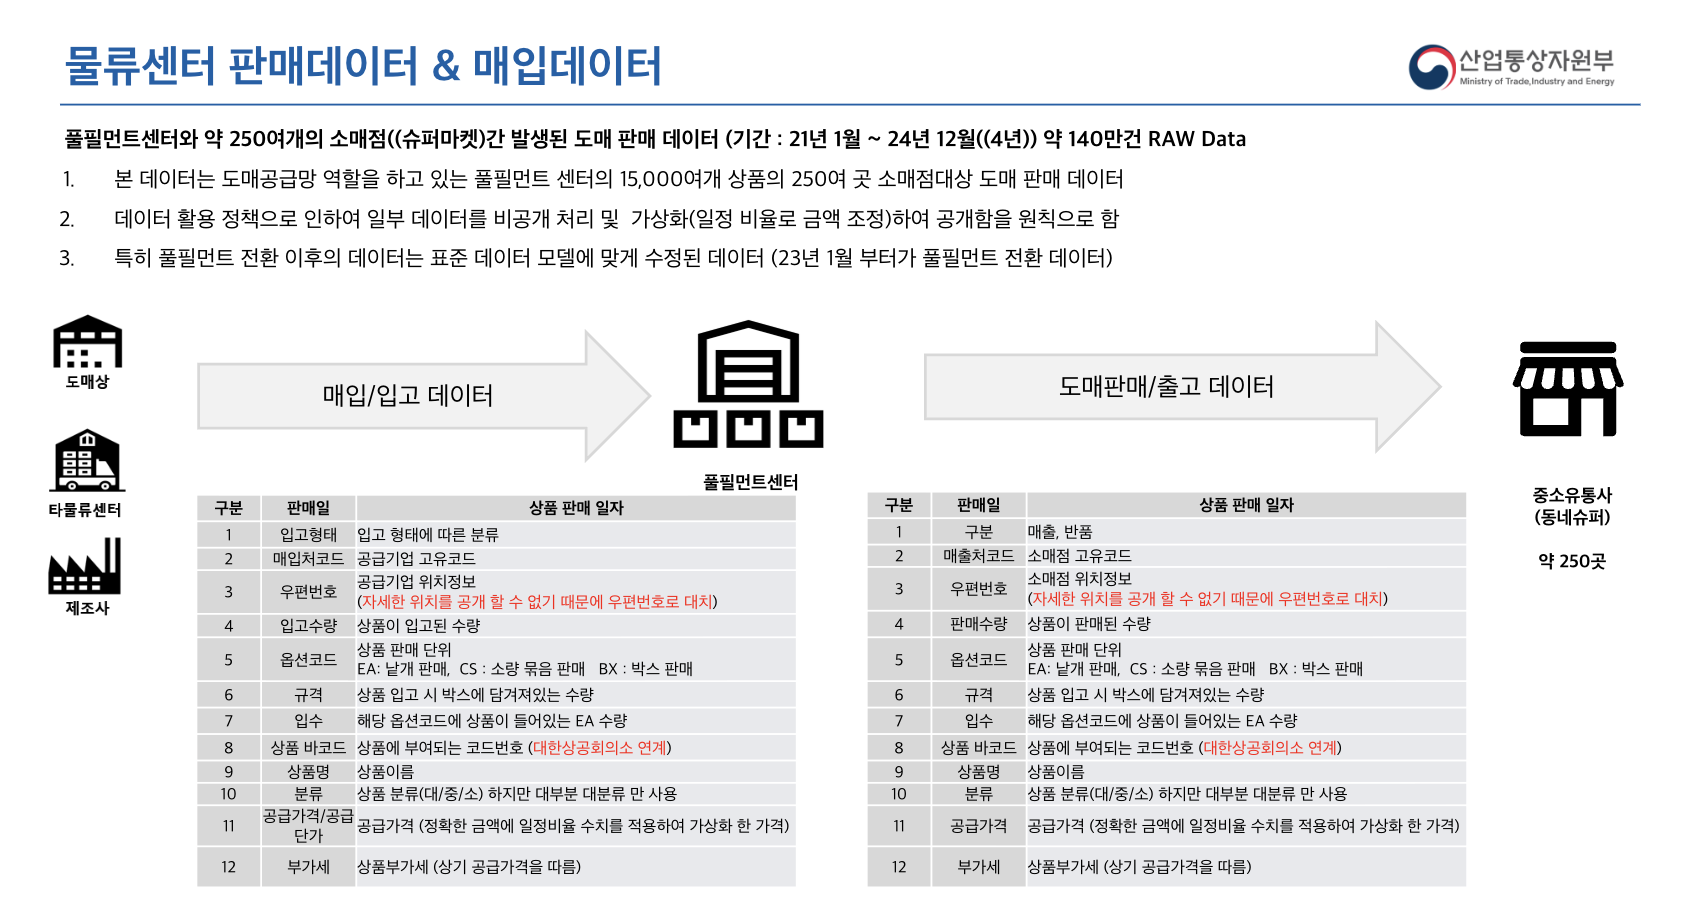

## 1. 분석 배경 
최근 유통산업은 경기 변동성 확대와 기후 변화로 인해 제품 수요의 불확실성이 커지고 있다. 

이에 따라 재고 과잉 및 품절 리스크를 최소화하고, 품목별 수요예측 모델의 필요성이 강조되고 있다.

## 2. 분석 목표
본 공모의 목표는 신선식품,생수·음료·건강,봉지라면,탄산음료의 월별 판매수량(EA)을 예측하고,

기온·강수량 등 기상요인, 물가지수(CPI), 소비자심리지수(CCSI)의 경제지표, 명절,COVID19의 사회·정책 외생 변수가 수요에 미치는 영향을 통계적으로 규명하는 것이다.

## 3. 데이터 수집

유통 공모전에서 제공한 A·B 물류센터의 매입 및 매출 데이터를 활용하였다.

분석 대상은 신선식품,생수·음료·건강,봉지라면,탄산음료4개 품목이며, 2021년부터 2024년까지의 월별 EA(판매수량) 데이터를 기반으로 하였다.

외부 변수는(기상, 경제, 사회·정책)를 통합하여 분석 데이터를 구성하였다.

팀원들과 나눠 분석을 진행하여 B 물류센터의 봉지라면과 탄산음료의 매입,매출 데이터만 사용한다.

- **품목**: 봉지라면, 탄산음료
- **데이터**: B물류센터 매입/매출 (2021.01 ~ 2024.12)
- **목표**: 데이터 정제 → 결측치/이상치 처리 → 파생변수 생성 → 스케일링/인코딩


## 4. 라이브러리 로드 및 환경 설정

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm 
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler 

In [2]:
# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    import subprocess
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    fm._load_fontmanager(try_read_cache=False)
    nanum_fonts = [f for f in fm.findSystemFonts() if 'Nanum' in f]
    if nanum_fonts:
        plt.rcParams['font.family'] = fm.FontProperties(fname=nanum_fonts[0]).get_name()

plt.rcParams['axes.unicode_minus'] = False


## 5. 데이터 로드


In [3]:
base = "/Users/danha/Desktop/IT/project/공모전/raw/data/"

라면_매입 = pd.read_csv(base + "B물류센터_봉지라면_매입.csv", encoding="cp949")
라면_매출 = pd.read_csv(base + "B물류센터_봉지라면_매출.csv", encoding="cp949")
탄산_매입 = pd.read_csv(base + "B물류센터_탄산음료_매입.csv", encoding="cp949")
탄산_매출 = pd.read_csv(base + "B물류센터_탄산음료_매출.csv", encoding="cp949")  


for name, df_tmp in [('봉지라면 매입', 라면_매입),
                      ('탄산음료 매입', 탄산_매입),
                      ('봉지라면 매출', 라면_매출),
                      ('탄산음료 매출', 탄산_매출)]:
    print(f'  {name}  shape={df_tmp.shape}  columns={df_tmp.columns.tolist()}')

print('\n봉지라면 매입')
display(라면_매입.head(3))
print('\n탄산음료 매출')
display(탄산_매출.head(3))


  봉지라면 매입  shape=(2961, 3)  columns=['일자', '수량', '소분류']
  탄산음료 매입  shape=(2132, 3)  columns=['일자', '수량', '소분류']
  봉지라면 매출  shape=(49376, 3)  columns=['판매일', '판매수량', '소분류']
  탄산음료 매출  shape=(32698, 3)  columns=['판매일', '판매수량', '소분류']

봉지라면 매입


,일자,수량,소분류
0,2021-01-05,1344,봉지라면
1,2021-01-05,80,봉지라면
2,2021-01-05,80,봉지라면



탄산음료 매출


,판매일,판매수량,소분류
0,2021-01-31,30,탄산음료
1,2021-01-31,24,탄산음료
2,2021-01-31,24,탄산음료


## 6. 데이터 전처리
매입, 매출 데이터에서 소분류가 탄산음료, 봉지라면 인 상품만을 분석 대상으로 설정했다.

봉지라면 데이터에서 (농심)포테이토칩_감자사발면맛 60g 비관련 품목을 제거하였다.



### 6.1 연-월별 판매수량 집계

In [4]:
# 일자를 일별 -> 월별 매입수량으로 변환
def prep_purchase_monthly(df_raw: pd.DataFrame) -> pd.DataFrame:
    x = df_raw.copy()

    if '일자' not in x.columns:
        raise ValueError(f'매입 데이터에 일자 컬럼이 없습니다: {x.columns.tolist()}')

    if '수량' in x.columns:
        qty_col = '수량'
    elif 'EA' in x.columns:
        qty_col = 'EA'
    else:
        raise ValueError(f'매입 수량 컬럼(EA/수량)을 찾지 못했습니다: {x.columns.tolist()}')

    x['일자'] = pd.to_datetime(x['일자'])
    x['연월'] = x['일자'].dt.to_period('M').dt.to_timestamp()

    return (x.groupby('연월', as_index=False)[qty_col]
             .sum()
             .rename(columns={qty_col: '매입수량'}))


# 일자를 일별 -> 월별 매출수량으로 변환
def prep_sales_monthly(df_raw: pd.DataFrame) -> pd.DataFrame:
    x = df_raw.copy()

    if '연월' in x.columns:
        x['연월'] = pd.to_datetime(x['연월']).dt.to_period('M').dt.to_timestamp()
    elif '판매일' in x.columns:
        x['연월'] = pd.to_datetime(x['판매일']).dt.to_period('M').dt.to_timestamp()
    else:
        raise ValueError(f'매출 데이터에 연월/판매일 컬럼이 없습니다: {x.columns.tolist()}')

    if '판매수량' in x.columns:
        qty_col = '판매수량'
    elif '매출수량' in x.columns:
        qty_col = '매출수량'
    else:
        raise ValueError(f'매출 수량 컬럼이 없습니다: {x.columns.tolist()}')

    return (x.groupby('연월', as_index=False)[qty_col]
             .sum()
             .rename(columns={qty_col: '매출수량'}))

# 월별 통합
def build_item_monthly(item_name, purchase_raw, sales_raw):
    purchase_m = prep_purchase_monthly(purchase_raw)
    sales_m    = prep_sales_monthly(sales_raw)

    min_month  = min(purchase_m['연월'].min(), sales_m['연월'].min())
    max_month  = max(purchase_m['연월'].max(), sales_m['연월'].max())
    month_grid = pd.DataFrame({'연월': pd.date_range(min_month, max_month, freq='MS')})

    item_df = (month_grid
               .merge(purchase_m, on='연월', how='left')
               .merge(sales_m,    on='연월', how='left'))

    item_df['매입수량'] = item_df['매입수량'].fillna(0)
    item_df['매출수량'] = item_df['매출수량'].fillna(0)
    item_df['품목']     = item_name

    return item_df


df_라면 = build_item_monthly('봉지라면', 라면_매입, 라면_매출)
df_탄산 = build_item_monthly('탄산음료', 탄산_매입, 탄산_매출)

df = pd.concat([df_라면, df_탄산], ignore_index=True)

df = (df[['연월', '매입수량', '매출수량', '품목']]
      .sort_values(['품목', '연월'])
      .reset_index(drop=True))

display(df.head(6))

save_path = "/Users/danha/Desktop/IT/project/공모전/공모전/raw/data"
df.to_csv(save_path + 'Model A - EA.csv', index=False, encoding='utf-8-sig')
print(f'Model A - EA.csv  →  {save_path}')

,연월,매입수량,매출수량,품목
0,2021-01-01,24209,3476,봉지라면
1,2021-02-01,19935,2214,봉지라면
2,2021-03-01,29570,4104,봉지라면
3,2021-04-01,26777,2631,봉지라면
4,2021-05-01,18407,3026,봉지라면
5,2021-06-01,16678,2411,봉지라면


Model A - EA.csv  →  /Users/danha/Desktop/IT/project/공모전/공모전/raw/data



### 6.2 결측치 탐색
결측치 없음


In [5]:
missing_total = df.isnull().sum()

for 품목, sub_df in df.groupby('품목'):
    print(f'\n--- {품목} 결측치 ---')
    print(sub_df.isnull().sum())



--- 봉지라면 결측치 ---
연월      0
매입수량    0
매출수량    0
품목      0
dtype: int64

--- 탄산음료 결측치 ---
연월      0
매입수량    0
매출수량    0
품목      0
dtype: int64



### 6.3 이상치 탐색 및 보정

봉지라면 매출 데이터 이상치 확인 결과, 상한치( Q3 + 1.5 × IQ)를 초과하는 값으로 확인되어, 해당 구간의 이상치를 상한치 값으로 대체한 후 분포가 안정화되었음을 확인하였다.


이상치 기준 :
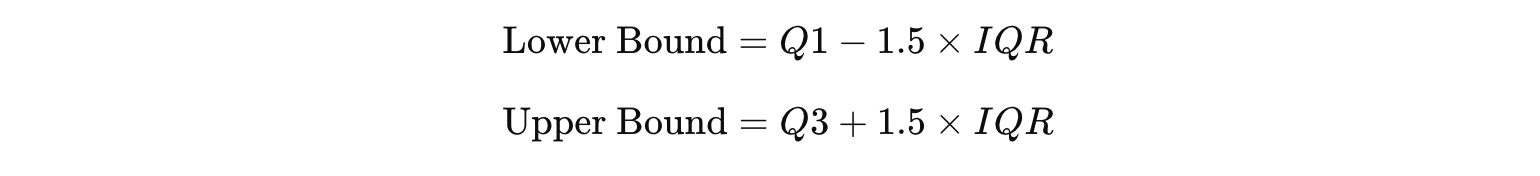

In [6]:
# IQR로 수량 이상치 탐색
def detect_outliers_iqr(series, label=''):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lb, ub = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    out = series[(series < lb) | (series > ub)]
    print(f'  [{label}]  Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}')
    print(f'  이상치 범위: ({lb:.0f}, {ub:.0f})  이상치 수: {len(out)}')
    if len(out):
        print(f'  이상치 값: {out.values}')
    return lb, ub

outlier_bounds = {}

for 품목 in ['봉지라면', '탄산음료']:
    sub = df[df['품목'] == 품목]
    print(f'\n {품목}')
    for col in ['매입수량', '매출수량']:
        lb, ub = detect_outliers_iqr(sub[col], f'{품목}_{col}')
        outlier_bounds[(품목, col)] = (lb, ub)



 봉지라면
  [봉지라면_매입수량]  Q1=17885  Q3=24366  IQR=6481
  이상치 범위: (8164, 34087)  이상치 수: 0
  [봉지라면_매출수량]  Q1=2446  Q3=2928  IQR=482
  이상치 범위: (1724, 3650)  이상치 수: 4
  이상치 값: [4104 4005 4413 5477]

 탄산음료
  [탄산음료_매입수량]  Q1=14194  Q3=22604  IQR=8410
  이상치 범위: (1580, 35218)  이상치 수: 0
  [탄산음료_매출수량]  Q1=14018  Q3=18667  IQR=4649
  이상치 범위: (7045, 25640)  이상치 수: 0


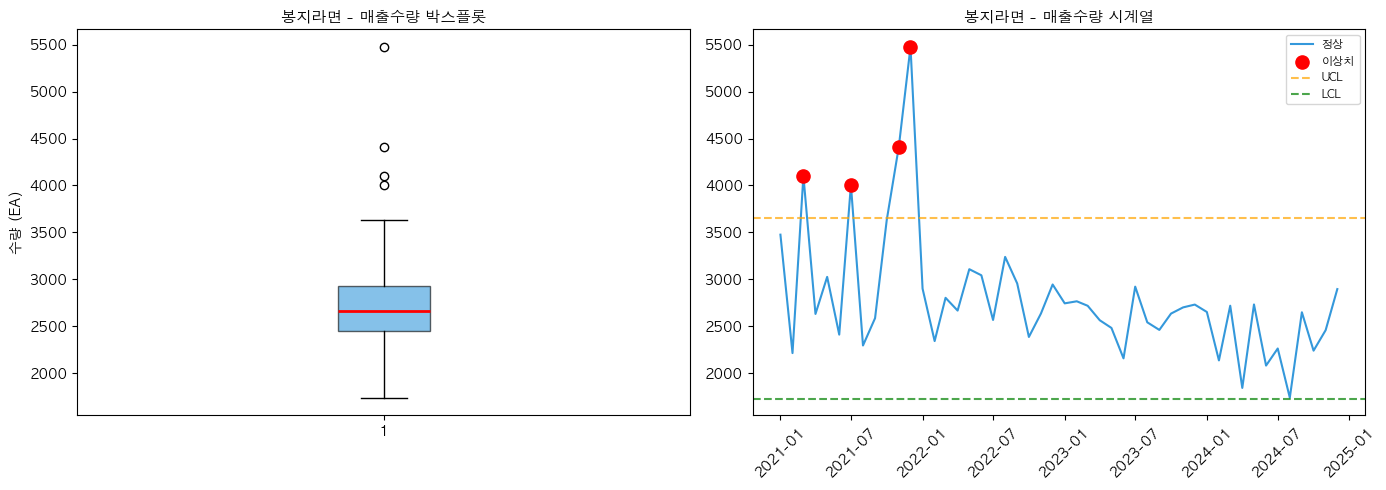

In [7]:
# 이상치 시각화
import matplotlib.pyplot as plt

품목 = '봉지라면'
col = '매출수량'

sub = df[df['품목'] == 품목]
lb, ub = outlier_bounds[(품목, col)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 박스플롯
axes[0].boxplot(sub[col].dropna(),
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title(f'{품목} - {col} 박스플롯', fontsize=11, fontweight='bold')
axes[0].set_ylabel('수량 (EA)')

# 시계열 + 이상치
normal = (sub[col] >= lb) & (sub[col] <= ub)

axes[1].plot(sub['연월'], sub[col],
             color='#3498db', linewidth=1.5, label='정상')

axes[1].scatter(sub.loc[~normal, '연월'],
                sub.loc[~normal, col],
                color='red', s=90, zorder=5, label='이상치')

axes[1].axhline(ub, color='orange', linestyle='--', alpha=0.7, label='UCL')
axes[1].axhline(lb, color='green', linestyle='--', alpha=0.7, label='LCL')

axes[1].set_title(f'{품목} - {col} 시계열', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [8]:
# 이상치 보정

df_clean = df.copy()

for 품목 in ['봉지라면', '탄산음료']:
    mask = df_clean['품목'] == 품목
    for col in ['매입수량', '매출수량']:
        lb, ub = outlier_bounds[(품목, col)]
        n_out = ((df_clean.loc[mask, col] < lb) | (df_clean.loc[mask, col] > ub)).sum()
        df_clean.loc[mask, col] = df_clean.loc[mask, col].clip(lower=lb, upper=ub)

print('\n이상치 보정 완료:')
display(df_clean.groupby('품목')[['매입수량', '매출수량']].describe().round(0))

df_clean.sort_values(['품목', '연월']).groupby('품목').head(5)

df_clean.to_csv(save_path + 'Model B - EA + 보정.csv', index=False, encoding='utf-8-sig')
print(f'Model B - EA + 보정.csv  →  {save_path}')


이상치 보정 완료:


매입수량                                                                \
     count     mean     std      min      25%      50%      75%      max   
품목                                                                         
봉지라면  48.0  21154.0  4584.0  13046.0  17885.0  20432.0  24366.0  33437.0   
탄산음료  48.0  18583.0  5147.0   7886.0  14194.0  18270.0  22604.0  26742.0   

      매출수량                                                                
     count     mean     std      min      25%      50%      75%      max  
품목                                                                        
봉지라면  48.0   2714.0   462.0   1739.0   2446.0   2660.0   2928.0   3650.0  
탄산음료  48.0  16216.0  3053.0  10183.0  14018.0  16337.0  18667.0  22228.0

Model B - EA + 보정.csv  →  /Users/danha/Desktop/IT/project/공모전/공모전/raw/data


### 6.4 봉지라면/탄산음료의 매입수량·매출수량 월 단위 시계열 그래프 확인

봉지라면 판매수량 단위가 매우 작고 반품이 존재하는 데이터 특성 차이로 봉지라면 매출 변동이 상대적으로 작게 표현되는 현상이 나타났다.

(매입은 물류센터가 제조사에서 박스째 입고하는 거고, 
매출은 소비자한테 낱개로 파는 거라 실제로 7~8배 차이가 난다.)


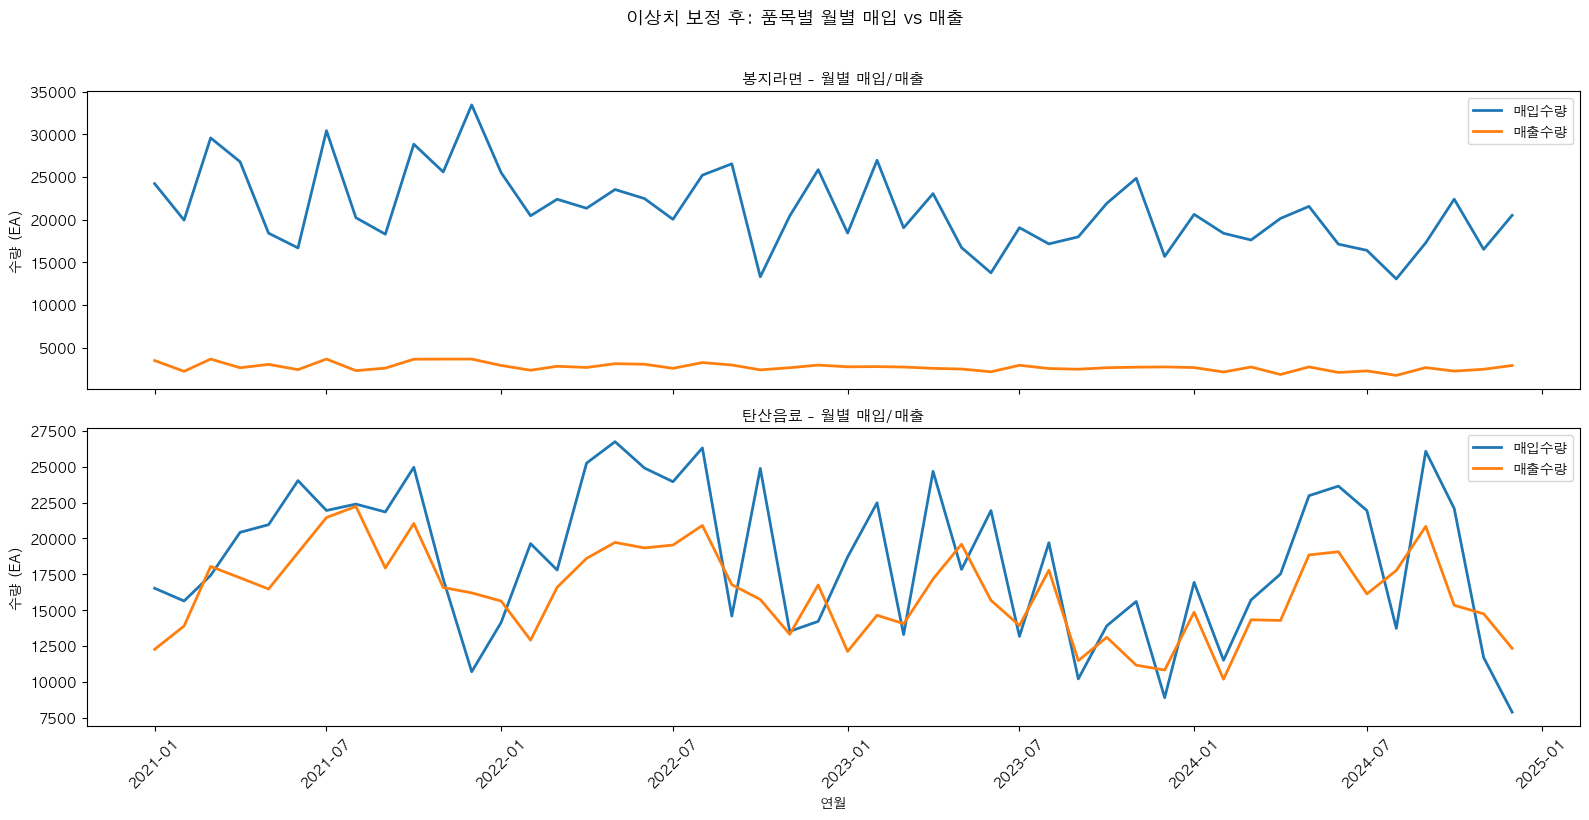

In [9]:

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for i, item in enumerate(['봉지라면', '탄산음료']):
    sub = df_clean[df_clean['품목'] == item].sort_values('연월')

    axes[i].plot(sub['연월'], sub['매입수량'], linewidth=2, label='매입수량')
    axes[i].plot(sub['연월'], sub['매출수량'], linewidth=2, label='매출수량')
    axes[i].set_title(f'{item} - 월별 매입/매출', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('수량 (EA)')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

axes[1].set_xlabel('연월')

plt.suptitle('이상치 보정 후: 품목별 월별 매입 vs 매출', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

봉지라면 매입수량과 매출수량을 표준화하여 비교한 결과 시계열 패턴은 유사하게 나타났다. 

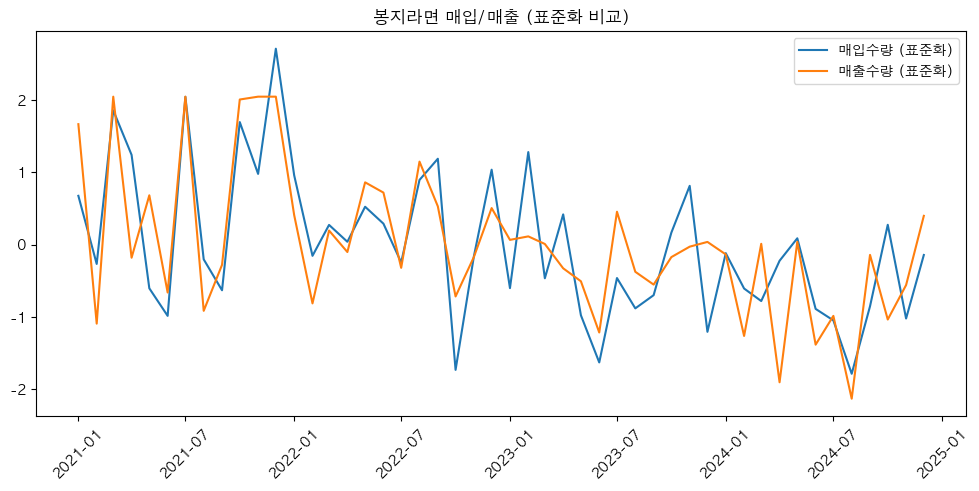

In [10]:
from sklearn.preprocessing import StandardScaler

sub = df_clean[df_clean['품목']=='봉지라면'].sort_values('연월')

scaler = StandardScaler()
scaled = scaler.fit_transform(sub[['매입수량','매출수량']])

plt.figure(figsize=(12,5))
plt.plot(sub['연월'], scaled[:,0], label='매입수량 (표준화)')
plt.plot(sub['연월'], scaled[:,1], label='매출수량 (표준화)')
plt.legend()
plt.xticks(rotation=45)
plt.title('봉지라면 매입/매출 (표준화 비교)')
plt.show()


## 7. 파생변수 생성 (외생변수)

매출은 단순히 과거 패턴만으로 결정되지 않는다고 판단하여 모델 성능을 높이기 위해 외생변수를 포함하기로 했다.

탄산음료와 봉지라면 모두 외부 환경이 수요에 영향을 준다는 점을 고려하여 아래의 파생변수를 선택했다.

 ( 수요=과거패턴+계절성+기후+가격+이벤트 )

| 구분 | 변수 |
|------|------|
| 기상 | 평균기온, 평균일교차, 강수량, 폭염일수, 한파일수 |
| 경제 | CPI |
| 사회·정책 | 명절, COVID-19 |
| 계절 | 여름_여부, 겨울_여부 |

In [11]:
raw_path = "/Users/danha/Desktop/IT/project/공모전/raw/"

hotest  = pd.read_excel(raw_path + "폭염일수.xlsx")
coldest = pd.read_excel(raw_path + "한파.xlsx")
weather = pd.read_excel(raw_path + "월별_전국_기온.xlsx")
rain    = pd.read_excel(raw_path + "강수량.xlsx")

# 평균기온, 평균일교차 계산 
weather['평균일교차'] = weather['평균최고기온(℃)'] - weather['평균최저기온(℃)']
weather['일자']      = weather['일시']
weather = weather[['일자', '평균기온(℃)', '평균일교차']]

# 기상 파일 이자 통합
add_df = pd.merge(hotest,  coldest, how='left', on='일자')
add_df = pd.merge(add_df,  weather, how='left', on='일자')
add_df = pd.merge(add_df,  rain,    how='left', on='일자')

# COVID_19: 2020-01 ~ 2022-04 = 1, 이후 = 0 
add_df['일자']      = pd.to_datetime(add_df['일자'])
add_df['COVID_19']  = (
    (add_df['일자'] >= pd.Timestamp('2020-01-01')) &
    (add_df['일자'] <= pd.Timestamp('2022-04-01'))
).astype(int)


add_df.head(5)


,일자,평균 폭염일수,평균 한파일수,평균기온(℃),평균일교차,강수량,COVID_19
0,2021-01-01,0.0,5.5,-1.1,10.8,19.9,1
1,2021-02-01,0.0,0.4,3.4,11.6,20.1,1
2,2021-03-01,0.0,0.0,8.7,11.7,110.7,1
3,2021-04-01,0.0,0.0,13.2,12.0,76.3,1
4,2021-05-01,0.0,0.0,16.6,10.8,143.8,1


In [12]:
# 생활물가지수: 라면·탄산음료 CPI 추출
#100 → 기준년도 가격
#105 → 기준 대비 5% 상승
#95 → 기준 대비 5% 하락

cpi_raw = pd.read_excel(raw_path + "생활물가지수.xlsx")

# 품목별 행 공백 제거 후 매칭
cpi_raw['품목별'] = cpi_raw['품목별'].str.strip()
cpi_라면 = cpi_raw[cpi_raw['품목별'] == '라면']
cpi_탄산 = cpi_raw[cpi_raw['품목별'] == '탄산음료']


def melt_cpi(df_wide, col_name):
    date_cols = [c for c in df_wide.columns if str(c)[0].isdigit()]
    long = df_wide[date_cols].T.reset_index()
    long.columns = ['일자', col_name]
    long['일자'] = pd.to_datetime(long['일자'].str.replace('.', '-', regex=False) + '-01')
    long[col_name] = pd.to_numeric(long[col_name], errors='coerce')
    return long

cpi_라면_long = melt_cpi(cpi_라면, 'CPI_라면')
cpi_탄산_long = melt_cpi(cpi_탄산, 'CPI_탄산')


cpi_df = pd.merge(cpi_라면_long, cpi_탄산_long, on='일자', how='outer').sort_values('일자').reset_index(drop=True)

cpi_df.head(10)


,일자,CPI_라면,CPI_탄산
0,2021-01-01,99.93,103.27
1,2021-02-01,99.79,103.79
2,2021-03-01,99.95,104.72
3,2021-04-01,99.30,105.91
4,2021-05-01,99.97,105.22
5,2021-06-01,100.50,104.55
6,2021-07-01,100.68,104.63
7,2021-08-01,100.74,102.58
8,2021-09-01,109.07,105.66
9,2021-10-01,110.03,106.31


In [13]:
#월별 집계
add_df = add_df.copy()
add_df['일자'] = pd.to_datetime(add_df['일자'])
add_df['연월'] = add_df['일자'].dt.to_period('M').dt.to_timestamp()


exog = add_df.groupby('연월', as_index=False).agg(
    폭염일수   = ('평균 폭염일수', 'mean'),
    한파일수   = ('평균 한파일수', 'mean'),
    평균기온   = ('평균기온(℃)',  'mean'),
    평균일교차 = ('평균일교차',   'mean'),
    강수량     = ('강수량',       'mean'),
).round(1)


cpi_df = cpi_df.copy()
cpi_df['일자'] = pd.to_datetime(cpi_df['일자'])
cpi_df['연월'] = cpi_df['일자'].dt.to_period('M').dt.to_timestamp()

#중복방지
cpi_m = (cpi_df
         .groupby('연월', as_index=False)[['CPI_라면', 'CPI_탄산']]
         .mean()
         .round(2))

exog = exog.merge(cpi_m, on='연월', how='left', validate='1:1')

# COVID_19 변수 생성 : 2020-01 ~ 2022-04 = 1, 이후 = 0 
exog['COVID_19'] = (
    (exog['연월'] >= pd.Timestamp('2020-01-01')) &
    (exog['연월'] <= pd.Timestamp('2022-04-01'))
).astype(int)

# 명절 변수 생성 : 설날·추석 포함 월 = 1 
holiday_months = ['2021-02','2021-09','2022-02','2022-09',
                  '2023-01','2023-09','2024-02','2024-09']
exog['명절'] = exog['연월'].dt.strftime('%Y-%m').isin(holiday_months).astype(int)



df_final = df_clean.merge(exog, on='연월', how='left', validate='m:1')


print('Shape:  ', df_final.shape)
print('Columns:', df_final.columns.tolist())
display(df_final.head(6))

df_final.to_csv(save_path + 'Model C - EA + 외생변수.csv', index=False, encoding='utf-8-sig')
print(f'Model C - EA + 외생변수.csv  →  {save_path}')

Shape:   (96, 13)
Columns: ['연월', '매입수량', '매출수량', '품목', '폭염일수', '한파일수', '평균기온', '평균일교차', '강수량', 'CPI_라면', 'CPI_탄산', 'COVID_19', '명절']


,연월,매입수량,매출수량,품목,폭염일수,한파일수,평균기온,평균일교차,강수량,CPI_라면,CPI_탄산,COVID_19,명절
0,2021-01-01,24209,3476,봉지라면,0.0,5.5,-1.1,10.8,19.9,99.93,103.27,1,0
1,2021-02-01,19935,2214,봉지라면,0.0,0.4,3.4,11.6,20.1,99.79,103.79,1,1
2,2021-03-01,29570,3650,봉지라면,0.0,0.0,8.7,11.7,110.7,99.95,104.72,1,0
3,2021-04-01,26777,2631,봉지라면,0.0,0.0,13.2,12.0,76.3,99.30,105.91,1,0
4,2021-05-01,18407,3026,봉지라면,0.0,0.0,16.6,10.8,143.8,99.97,105.22,1,0
5,2021-06-01,16678,2411,봉지라면,0.1,0.0,21.7,9.2,91.6,100.50,104.55,1,0


Model C - EA + 외생변수.csv  →  /Users/danha/Desktop/IT/project/공모전/공모전/raw/data



## 10. 스케일링 및 인코딩

### MinMaxScaler 변수 간 크기 균형과 학습 안정화를 위해 0 ~ 1 사이로 정규화

In [15]:
from sklearn.preprocessing import MinMaxScaler

base_num_cols  = ['매입수량', '매출수량']
exog_num_cols  = ['평균기온', '평균일교차', '강수량', '폭염일수', '한파일수',
                  'CPI_라면', 'CPI_탄산']
binary_cols    = ['COVID_19', '명절']

scale_cols = base_num_cols + [c for c in exog_num_cols if c in df_final.columns]

scaler    = MinMaxScaler()
df_scaled = df_final.copy()
df_scaled[scale_cols] = scaler.fit_transform(df_final[scale_cols])

# 이진 변수 정수 확인
for col in binary_cols:
    if col in df_scaled.columns:
        df_scaled[col] = df_scaled[col].round().astype(int)

# 품목 이진 인코딩 (봉지라면=0, 탄산음료=1)
df_scaled['품목_코드'] = (df_scaled['품목'] == '탄산음료').astype(int)


cols_show = [
    '연월', '품목',
    '매입수량', '매출수량',
    '평균기온', '평균일교차', '강수량',
    '폭염일수', '한파일수',
    'CPI_라면', 'CPI_탄산'
]
cols_show = [c for c in cols_show if c in df_scaled.columns]

display(
    df_scaled
    .sort_values(['품목', '연월'])
    .groupby('품목')[cols_show]
    .head(5)
)

df_scaled.to_csv(save_path + 'scaled.csv', index=False, encoding='utf-8-sig')
print(f'scaled.csv  →  {save_path}')


,연월,품목,매입수량,매출수량,평균기온,평균일교차,강수량,폭염일수,한파일수,CPI_라면,CPI_탄산
0,2021-01-01,봉지라면,0.638840,0.084777,0.010239,0.583333,0.034359,0.0,1.000000,0.024813,0.043699
1,2021-02-01,봉지라면,0.471567,0.023183,0.163823,0.694444,0.034757,0.0,0.072727,0.019299,0.076631
2,2021-03-01,봉지라면,0.848656,0.093270,0.344710,0.708333,0.214697,0.0,0.000000,0.025601,0.135529
3,2021-04-01,봉지라면,0.739345,0.043536,0.498294,0.750000,0.146375,0.0,0.000000,0.000000,0.210893
4,2021-05-01,봉지라면,0.411765,0.062814,0.614334,0.583333,0.280437,0.0,0.000000,0.026388,0.167194
48,2021-01-01,탄산음료,0.338030,0.513788,0.010239,0.583333,0.034359,0.0,1.000000,0.024813,0.043699
49,2021-02-01,탄산음료,0.303315,0.593050,0.163823,0.694444,0.034757,0.0,0.072727,0.019299,0.076631
50,2021-03-01,탄산음료,0.373293,0.795646,0.344710,0.708333,0.214697,0.0,0.000000,0.025601,0.135529
51,2021-04-01,탄산음료,0.490627,0.757089,0.498294,0.750000,0.146375,0.0,0.000000,0.000000,0.210893
52,2021-05-01,탄산음료,0.511448,0.719069,0.614334,0.583333,0.280437,0.0,0.000000,0.026388,0.167194


scaled.csv  →  /Users/danha/Desktop/IT/project/공모전/공모전/raw/data


## 11. 회고

- 일별 데이터를 월별로 집계하고, 품목별로 데이터 구조를 만들어 결측치 및 이상치를 처리하고, 

    외생 변수 결합을 직접 해보면서 모델링을 하기위해 깨끗하게 정리된 데이터 구조가 정말 중요하단 것을 알았다.

- CPI와 기상 데이터는 단순 병합이 아닌, 시계열 기준을 맞춰야 한다는 점에서 많은 시행착오를 겪었다.

- 또한 스케일링과 인코딩을 하며 LSTM은 트리 모델과 달리 스케일에 민감하다는 점을 알게되어서 

    변수 간 스케일 차이가 학습에 영향을 준다는 개념 이해했다.